In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn import svm
from time import time
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, precision_score, recall_score


from sklearn.pipeline import make_pipeline

In [2]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)
        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

In [3]:
# Loads features and target variables
def load_data(filename, y_target_name):
    df = pd.read_csv(filename)
    X = df.drop(columns=[y_target_name])
    y = df[y_target_name]

    return X, y, df

In [4]:
def show_corr_matrix(df, output_filename):
    non_valid_cols = [
        df.columns[i]
        for i, item in enumerate(df.dtypes)
        if not pd.api.types.is_numeric_dtype(item)
    ]
    df.drop(columns=non_valid_cols, inplace=True)
    matrix = df.corr()
    plt.figure(figsize=(32, 16))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("UCI Phishing URL Correlation Heatmap")
    plt.savefig(output_filename)

In [5]:
def get_training_test_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

In [6]:
# U are hyperparam tuning here


def logistic_regression_model_training(X_train, X_test, y_train, y_test):
    C_grid = np.logspace(-4, 4, 10)
    y_train_log_loss_data = []
    y_test_log_loss_data = []
    for i, C in enumerate(C_grid):
        print("working on i")
        clf = LogisticRegression(C=C, penalty="l2", solver="lbfgs", max_iter=1000).fit(
            X_train, y_train
        )
        y_train_pred = clf.predict_proba(X_train)
        y_test_pred = clf.predict_proba(X_test)
        y_train_log_loss = log_loss(y_train, y_train_pred)
        y_test_log_loss = log_loss(y_test, y_test_pred)

        y_train_log_loss_data.append(y_train_log_loss)
        y_test_log_loss_data.append(y_test_log_loss)

    plt.figure()
    plt.plot(
        C_grid,
        y_train_log_loss_data,
        "o-",
        color="blue",
        label="Training Data Log-Loss",
        markersize=3,
    )
    plt.plot(
        C_grid,
        y_test_log_loss_data,
        "o-",
        color="red",
        label="Test Data Log-Loss",
        markersize=3,
    )

    plt.xlabel("C")
    plt.ylabel("Log-Loss")
    plt.title("Log-Loss of Training and Test Data Vs C")
    plt.ylim([0, 3])
    plt.xscale("log")
    plt.legend()
    plt.savefig("../outputs/logistic_regression_log_loss_c.png")

## Create pipelines for different models


In [7]:
# TODO: Add steps here
KNN_pipeline = make_pipeline(None, KNeighborsClassifier())
DT_pipeline = make_pipeline(None, DecisionTreeClassifier())
DT_model = DecisionTreeClassifier()
random_forest_pipeline = make_pipeline(None, RandomForestClassifier())
SGD_pipeline = make_pipeline(None, SGDClassifier())
linearSVM_pipeline = make_pipeline(None, svm.LinearSVR())

In [8]:
def evaluate_model(pipeline: Pipeline, X_data: pd.DataFrame, y_true: np.array):
    start = time()
    y_pred = pipeline.predict(X_data)
    end = time()
    latency = round((end - start) * 1000, 1)
    accuracy = round(
        accuracy_score(
            y_true,
            y_pred,
        ),
        3,
    )
    precision = round(precision_score(y_true, y_pred, average="weighted"), 3)
    recall = round(
        recall_score(
            y_true,
            y_pred,
        ),
        3,
    )

    print(f"Split ratio is: ")
    model = pipeline[1]
    print(
        f"param: {model} -- Accuracy: {accuracy} / Precision: {precision} / Recall: {recall} / Prediction Latency: {latency}ms"
    )
    conf = confusion_matrix(y_true, y_pred)
    print("Confusion matrix is:")
    print(conf)
    print("_____________________________________________________")

In [ ]:
clean_csv(
    "../data/uci_phishing_url_dataset.csv",
    "../data/uci_phishing_url_dataset_clean_original_researchers.csv",
    ["URL", "Domain", "TLD", "Title"],
)

file: "./data/uci_phishing_url_dataset.csv" clean failed ([Errno 2] No such file or directory: './data/uci_phishing_url_dataset.csv')


False

remove "FILENAME" column from data


In [19]:
X, y, df = load_data(
    "../data/uci_phishing_url_dataset_clean_original_researchers.csv", "IsLegit"
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/uci_phishing_url_dataset_clean_original_researchers.csv'

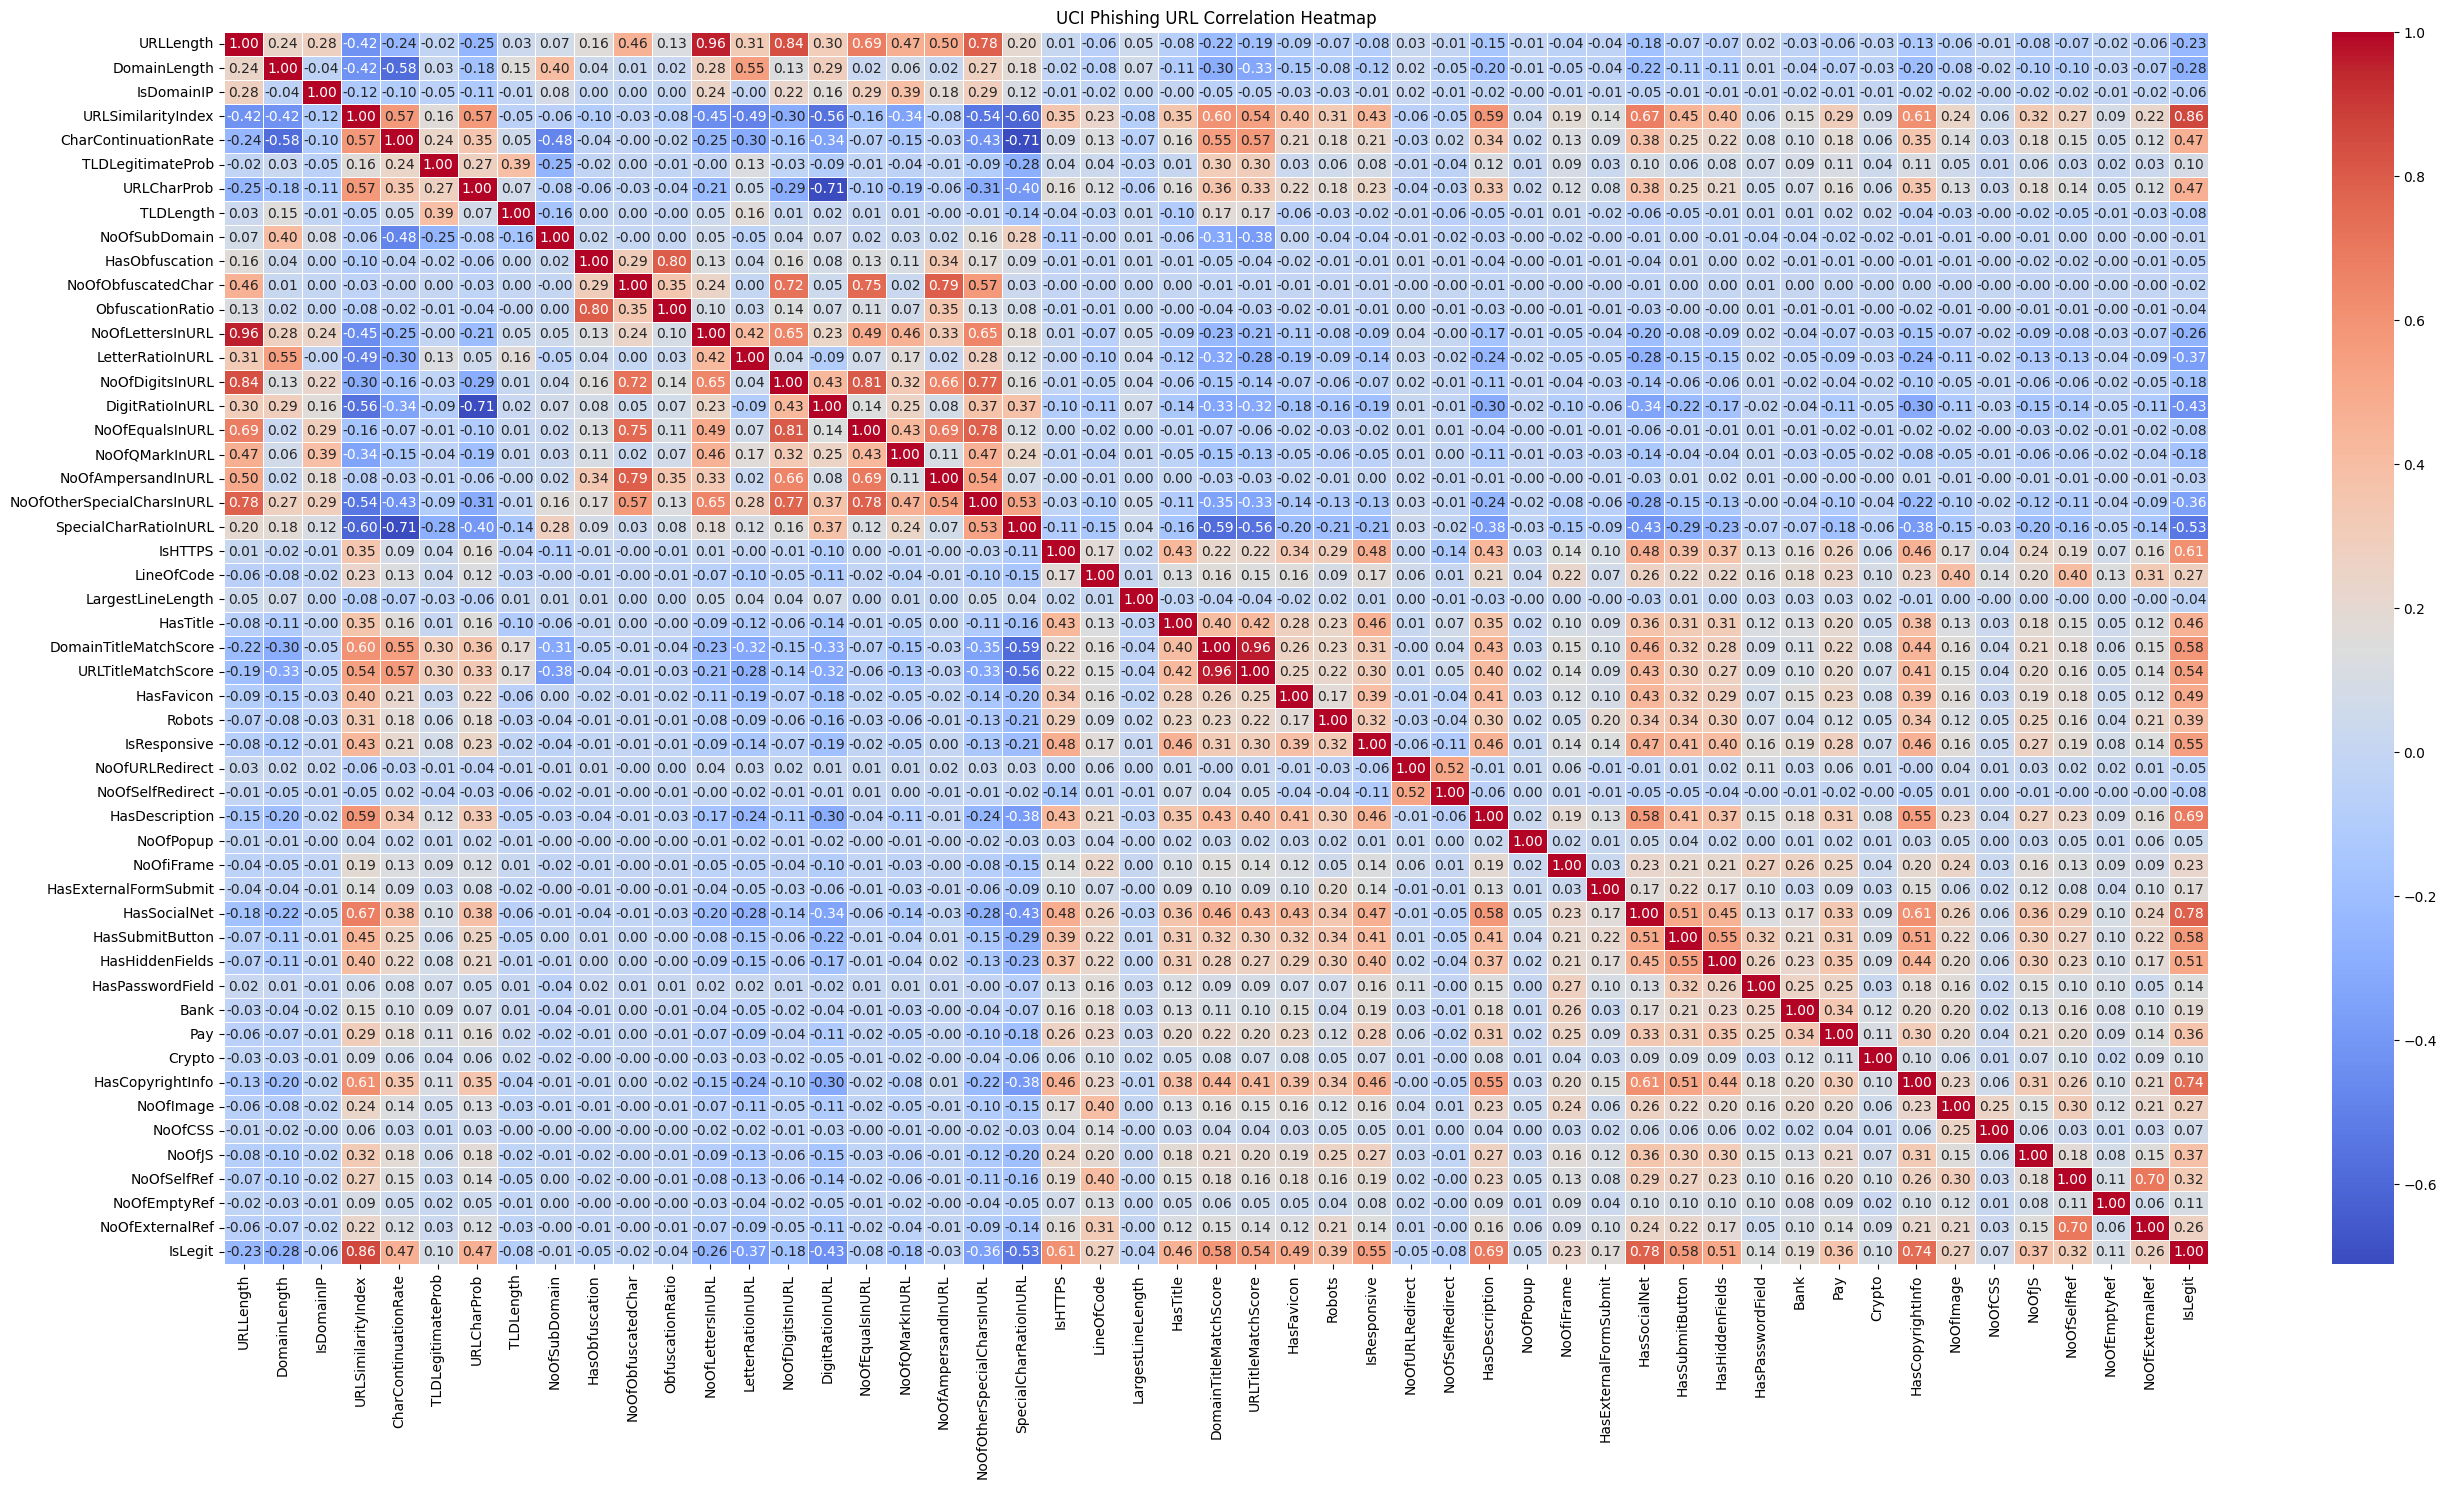

In [11]:
show_corr_matrix(df, "../outputs/uci_phishing_url_corr_matrix.png")

In [12]:
X_train, X_test, y_train, y_test = get_training_test_data(X, y)

working on i


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


working on i


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


working on i


...

/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


working on i


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


working on i


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


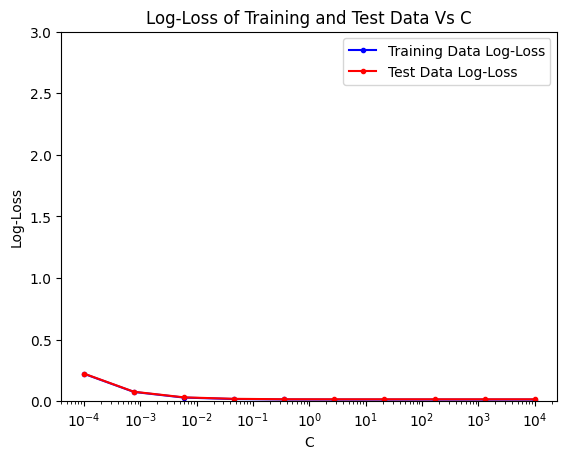

In [ ]:
logistic_regression_model_training(X_train, X_test, y_train, y_test)

# Train the models in the pipeline


In [13]:
KNN_pipeline.fit(X_train, y_train)
DT_pipeline.fit(X_train, y_train)
DT_model.fit(X_train, y_train)

random_forest_pipeline.fit(X_train, y_train)
SGD_pipeline.fit(X_train, y_train)
linearSVM_pipeline.fit(X_train, y_train)

ValueError: could not convert string to float: 'https://www.lilybloomflorist.ie'

In [16]:
DT_model.feature_importances_

array([0.0026507 , 0.01766146, 0.        , 0.00075151, 0.06384721,
       0.        , 0.        , 0.        , 0.00091469, 0.04339143,
       0.01047532, 0.00552387, 0.        , 0.        , 0.        ,
       0.47760939, 0.00462301, 0.37255141])

## Check the pipeline


In [ ]:
evaluate_model(DT_pipeline, X_test, y_test)

DT_model.fit(X_test, y_test)
DT_model.feature_importances_

Split ratio is: 
param: DecisionTreeClassifier() -- Accuracy: 0.997 / Precision: 0.997 / Recall: 0.999 / Prediction Latency: 7.6ms
Confusion matrix is:
[[25120   156]
 [   33 33640]]
_____________________________________________________


array([0.00120808, 0.01372758, 0.        , 0.0013392 , 0.06154167,
       0.        , 0.        , 0.        , 0.00186888, 0.03874519,
       0.01276384, 0.00103252, 0.        , 0.        , 0.        ,
       0.47972021, 0.01208111, 0.37597173])

### See the steps that the model took to explain why it was safe :D

In [ ]:
print(DT_model.decision_path(X_test.iloc[[1]]))

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 18 stored elements and shape (1, 633)>
  Coords	Values
  (0, 0)	1
  (0, 2)	1
  (0, 3)	1
  (0, 5)	1
  (0, 6)	1
  (0, 7)	1
  (0, 8)	1
  (0, 9)	1
  (0, 10)	1
  (0, 11)	1
  (0, 12)	1
  (0, 13)	1
  (0, 14)	1
  (0, 15)	1
  (0, 16)	1
  (0, 17)	1
  (0, 51)	1
  (0, 53)	1


In [ ]:
DT_model.predict()
DT_model.feature_importances_

In [ ]:
evaluate_model(KNN_pipeline, X_test, y_test)

Split ratio is: 
param: KNeighborsClassifier() -- Accuracy: 0.997 / Precision: 0.997 / Recall: 0.999 / Prediction Latency: 53525.1ms
Confusion matrix is:
[[25132   144]
 [   31 33642]]
_____________________________________________________


In [ ]:
evaluate_model(random_forest_pipeline, X_test, y_test)

Split ratio is: 
param: RandomForestClassifier() -- Accuracy: 1.0 / Precision: 1.0 / Recall: 1.0 / Prediction Latency: 440.9ms
Confusion matrix is:
[[25276     0]
 [    0 33673]]
_____________________________________________________


In [35]:
evaluate_model(SGD_pipeline, X_test, y_test)

Split ratio is: 
param: SGDClassifier() -- Accuracy: 0.991 / Precision: 0.991 / Recall: 0.997 / Prediction Latency: 19.2ms
Confusion matrix is:
[[24862   414]
 [  108 33565]]
_____________________________________________________


In [36]:
# evaluate_model(linearSVM_pipeline, X_test, y_test)

ValueError: Classification metrics can't handle a mix of binary and continuous targets